<a href="https://colab.research.google.com/github/Pradss789/Experiment-Challenge-Credit-Default-Prediction/blob/main/Experiment_Challange_Credit_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Prediksi Modern & Machine Learning
## Experiment Challenge: Credit Default Prediction

Nama: Rama Pradito  
NIM: 2404220046
Program Studi: Statistika dan Sains Data

### Tujuan
Membangun dan membandingkan beberapa model machine learning untuk memprediksi
default pembayaran kartu kredit pada bulan berikutnya.

Target:
- 0 = Tidak Default
- 1 = Default

Metrik utama: F1-score

**0. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

**Experiment 0 — Data Understanding & Preparation**

0.1 Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv


In [ ]:
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


0.2 Dimensi Dataset

In [ ]:
print("Jumlah observasi :", df.shape[0])
print("Jumlah variabel  :", df.shape[1])

df.shape

Jumlah observasi : 30000
Jumlah variabel  : 25


(30000, 25)

Dataset terdiri dari 30000 observasi dan 25 variabel.

0.3 Struktur dan Tipe Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
df.dtypes

,0
ID,int64
LIMIT_BAL,float64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


0.4 Nama Seluruh Variabel

In [ ]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

0.5 Missing Value

In [ ]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing": missing,
    "Percentage": (missing / len(df)) * 100
})

missing_table[missing_table["Missing"] > 0]

,Missing,Percentage


In [ ]:
print("Total missing value:", df.isnull().sum().sum())

Total missing value: 0


**Interpretasi:**  
Tidak ditemukan missing value pada dataset. Oleh karena itu, tidak diperlukan
proses imputasi atau penghapusan observasi akibat data yang hilang.

0.6 Duplicate

In [ ]:
print("Jumlah duplicate:", df.duplicated().sum())

Jumlah duplicate: 0


In [ ]:
df_without_id = df.drop(columns=["ID"])

print(
    "Duplicate jika ID diabaikan:",
    df_without_id.duplicated().sum()
)

Duplicate jika ID diabaikan: 35


**Interpretasi:**  
Tidak terdapat baris yang sepenuhnya duplikat ketika variabel ID disertakan.
Namun, terdapat 35 observasi dengan kombinasi nilai predictor dan target yang
sama ketika ID diabaikan. Observasi tersebut tidak dihapus karena ID
merepresentasikan nasabah yang berbeda, sehingga kesamaan karakteristik tidak
secara otomatis menunjukkan duplikasi data.

0.7 Pemeriksaan Nilai Kategorikal

In [ ]:
categorical_check = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_check:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().sort_index())


===== SEX =====
SEX
1    11888
2    18112
Name: count, dtype: int64

===== EDUCATION =====
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

===== MARRIAGE =====
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [ ]:
df["AGE"].describe()

,AGE
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


In [ ]:
df["LIMIT_BAL"].describe()

,LIMIT_BAL
count,30000.000000
mean,167484.322667
std,129747.661567
min,10000.000000
25%,50000.000000
50%,140000.000000
75%,240000.000000
max,1000000.000000


**Interpretasi:**  
Variabel kategorikal memiliki beberapa kode kategori yang berbeda. Pada
EDUCATION ditemukan kategori 0–6, sedangkan pada MARRIAGE ditemukan kategori
0–3. Nilai tersebut dipertahankan sebagaimana terdapat pada raw dataset dan
akan diperlakukan sebagai kategori pada tahap preprocessing. Tidak dilakukan
penghapusan atau perubahan kategori secara langsung agar tidak mengubah data
tanpa dasar yang jelas.

Variabel AGE memiliki rentang 21–79 tahun, sedangkan LIMIT_BAL berada pada
rentang 10.000–1.000.000. Nilai tersebut dipertahankan dan tidak dilakukan
penghapusan berdasarkan rentang tersebut.

0.8 Pemeriksaan Status Pembayaran

In [ ]:
pay_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in pay_status_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().sort_index())


===== PAY_0 =====
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

===== PAY_2 =====
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

===== PAY_3 =====
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

===== PAY_4 =====
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

===== PAY_5 =====
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

===== PAY_6 =====
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49


**Interpretasi:**  
Variabel PAY_0 sampai PAY_6 menunjukkan beberapa kategori status pembayaran
dengan rentang nilai dari -2 hingga 8. Nilai-nilai tersebut dipertahankan
sebagaimana terdapat pada raw dataset dan digunakan sebagai predictor dalam
pemodelan.

0.9 Distribusi Target

In [ ]:
target = "default.payment.next.month"

target_count = df[target].value_counts().sort_index()
target_percentage = df[target].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Jumlah": target_count,
    "Persentase (%)": target_percentage
})

target_summary

,Jumlah,Persentase (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


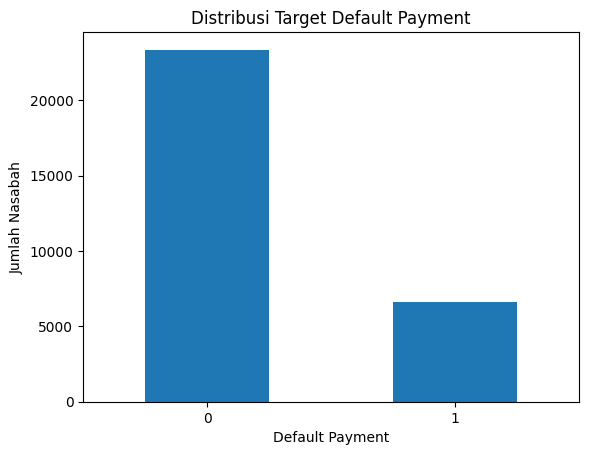

In [ ]:
df[target].value_counts().sort_index().plot(kind="bar")

plt.title("Distribusi Target Default Payment")
plt.xlabel("Default Payment")
plt.ylabel("Jumlah Nasabah")
plt.xticks(rotation=0)

plt.show()

**Interpretasi:**  
Distribusi target menunjukkan bahwa 77,88% nasabah tidak mengalami default
(kelas 0), sedangkan 22,12% mengalami default (kelas 1). Dengan demikian,
terdapat ketidakseimbangan kelas pada target. Oleh karena itu, F1-score
digunakan sebagai metrik utama sesuai ketentuan UTS karena mempertimbangkan
precision dan recall.

0.10 Tentukan X dan y

In [ ]:
X = df.drop(columns=["ID", target])
y = df[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (30000, 23)
Shape y: (30000,)


**Interpretasi:**  
Variabel ID dikeluarkan dari predictor karena hanya berfungsi sebagai
identifier nasabah dan tidak digunakan dalam pemodelan. Setelah penghapusan ID
dan target, diperoleh 23 variabel predictor.

0.11 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 23)
X_test : (6000, 23)
y_train: (24000,)
y_test : (6000,)


In [ ]:
print("Distribusi target training:")
print(y_train.value_counts(normalize=True))

print("\nDistribusi target testing:")
print(y_test.value_counts(normalize=True))

Distribusi target training:
default.payment.next.month
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Distribusi target testing:
default.payment.next.month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


**Interpretasi:**  
Dataset dibagi menjadi 80% training data (24.000 observasi) dan 20% testing
data (6.000 observasi). Parameter stratify=y digunakan agar proporsi kelas
default dan non-default pada training dan testing set tetap konsisten.
Train-test split dilakukan sebelum proses fitting preprocessing untuk
menghindari data leakage.

### Kesimpulan Experiment 0

Berdasarkan proses data understanding dan data preparation, dataset tidak
memiliki missing value maupun baris yang sepenuhnya duplikat. Variabel ID
dikeluarkan dari predictor karena hanya berfungsi sebagai identifier.

Distribusi target menunjukkan adanya ketidakseimbangan kelas, dengan 77,88%
observasi berada pada kelas non-default dan 22,12% pada kelas default. Dataset
kemudian dibagi menjadi 80% training set dan 20% testing set menggunakan
stratified split.

Preprocessing tambahan seperti feature scaling dan encoding belum diterapkan
pada baseline Experiment 1. Pengaruh preprocessing tersebut akan diuji secara
khusus pada Experiment 2 sehingga performanya dapat dibandingkan secara
langsung dengan baseline.

Fungsi Evaluasi

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def evaluate_model(model, X_train, y_train, X_test, y_test):

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        "CV F1": cv_scores.mean(),
        "CV F1 Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0)
    }

    return results

# Experiment 1 — Baseline Model

Pada eksperimen pertama digunakan Logistic Regression sebagai baseline.
Model dibangun menggunakan data awal tanpa preprocessing tambahan seperti
feature scaling dan encoding.

Evaluasi dilakukan menggunakan 5-fold cross validation pada training set dan
evaluasi pada test set.

In [ ]:
baseline_model = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)

result_exp1 = evaluate_model(
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([result_exp1], index=["Experiment 1"])

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment 1,0.3692,0.013464,0.808167,0.6841,0.24642,0.362327


In [ ]:
baseline_model.fit(X_train, y_train)

y_pred_exp1 = baseline_model.predict(X_test)

print(classification_report(y_test, y_pred_exp1))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.68      0.25      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [ ]:
confusion_matrix(y_test, y_pred_exp1)

array([[4522,  151],
       [1000,  327]])

**EXPERIMENT 2 — Preprocessing**

In [ ]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]
numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numeric_features)

Categorical:
['SEX', 'EDUCATION', 'MARRIAGE']

Numerical:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)
logreg_preprocessed = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

Evaluasi

In [ ]:
result_exp2 = evaluate_model(
    logreg_preprocessed,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([result_exp2], index=["Experiment 2"])

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment 2,0.366214,0.015176,0.808833,0.692308,0.24416,0.361003


Bandingkan Experiment 1 vs 2

In [ ]:
comparison_exp1_exp2 = pd.DataFrame([
    {
        "Experiment": "Exp 1 - Baseline",
        **result_exp1
    },
    {
        "Experiment": "Exp 2 - Preprocessing",
        **result_exp2
    }
])

comparison_exp1_exp2

,Experiment,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Exp 1 - Baseline,0.369200,0.013464,0.808167,0.684100,0.24642,0.362327
1,Exp 2 - Preprocessing,0.366214,0.015176,0.808833,0.692308,0.24416,0.361003


**EXPERIMENT 3 — Model Comparison**

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}
exp3_results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    result = evaluate_model(
        pipeline,
        X_train,
        y_train,
        X_test,
        y_test
    )

    result["Model"] = model_name

    exp3_results.append(result)

exp3_df = pd.DataFrame(exp3_results)

exp3_df

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Model
0,0.366214,0.015176,0.808833,0.692308,0.244160,0.361003,Logistic Regression
1,0.398361,0.010935,0.718500,0.373072,0.400904,0.386487,Decision Tree
2,0.470879,0.011556,0.810500,0.624346,0.359457,0.456241,Random Forest


In [ ]:
exp3_df.sort_values(
    by="CV F1",
    ascending=False
)

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Model
2,0.470879,0.011556,0.810500,0.624346,0.359457,0.456241,Random Forest
1,0.398361,0.010935,0.718500,0.373072,0.400904,0.386487,Decision Tree
0,0.366214,0.015176,0.808833,0.692308,0.244160,0.361003,Logistic Regression


In [ ]:
best_model_name = exp3_df.loc[
    exp3_df["CV F1"].idxmax(),
    "Model"
]

print("Model terbaik Experiment 3:", best_model_name)

Model terbaik Experiment 3: Random Forest


**EXPERIMENT 4 — Hyperparameter Tuning**

In [ ]:
if best_model_name == "Logistic Regression":

    selected_model = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    )

    param_grid = {
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    }


elif best_model_name == "Decision Tree":

    selected_model = DecisionTreeClassifier(
        random_state=RANDOM_STATE
    )

    param_grid = {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5],
        "model__class_weight": [None, "balanced"]
    }


elif best_model_name == "Random Forest":

    selected_model = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__class_weight": [None, "balanced"]
    }

In [ ]:
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", selected_model)
    ]
)
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['LIMIT_BAL',
                                                                          'AGE',
                                                                          'PAY_0',
                                                                          'PAY_2',
                                                                          'PAY_3',
                                                                          'PAY_4',
                                                                          'PAY_5',
                                                                          'PAY_6',
                                                                          'BILL_AMT1',
                                                                          'BILL_AMT2',
                                                                          'BILL_AMT3',
                                                                          'BILL_AMT4',
                                                                          'BILL_AMT5',
                                                                          'BILL_AMT6',
                                                                          'PAY_AMT1',
                                                                          'PAY_AMT2',
                                                                          'PAY_AMT3',
                                                                          'PAY_AM...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['SEX',
                                                                          'EDUCATION',
                                                                          'MARRIAGE'])])),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [5, 10, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best CV F1:
0.5447134081892578


Evaluasi Tuned Model

In [ ]:
best_tuned_model = grid_search.best_estimator_

y_pred_exp4 = best_tuned_model.predict(X_test)

result_exp4 = {
    "CV F1": grid_search.best_score_,
    "Test Accuracy": accuracy_score(y_test, y_pred_exp4),
    "Test Precision": precision_score(y_test, y_pred_exp4, zero_division=0),
    "Test Recall": recall_score(y_test, y_pred_exp4, zero_division=0),
    "Test F1": f1_score(y_test, y_pred_exp4, zero_division=0)
}

pd.DataFrame([result_exp4], index=["Experiment 4"])

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment 4,0.544713,0.786167,0.514986,0.569706,0.540966


**EXPERIMENT 5 — Advanced Model**

In [ ]:
advanced_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)
advanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", advanced_model)
    ]
)

In [ ]:
result_exp5 = evaluate_model(
    advanced_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([result_exp5], index=["Experiment 5"])

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment 5,0.479728,0.007034,0.818667,0.664374,0.363979,0.470302


**FINAL ANALYSIS**

In [ ]:
best_exp3 = exp3_df.loc[
    exp3_df["CV F1"].idxmax()
]

In [60]:
final_results = pd.DataFrame([

    {
        "Experiment": "1",
        "Model": "Logistic Regression - Baseline",
        "CV F1": result_exp1["CV F1"],
        "Test Accuracy": result_exp1["Test Accuracy"],
        "Test Precision": result_exp1["Test Precision"],
        "Test Recall": result_exp1["Test Recall"],
        "Test F1": result_exp1["Test F1"]
    },

    {
        "Experiment": "2",
        "Model": "Logistic Regression + Preprocessing",
        "CV F1": result_exp2["CV F1"],
        "Test Accuracy": result_exp2["Test Accuracy"],
        "Test Precision": result_exp2["Test Precision"],
        "Test Recall": result_exp2["Test Recall"],
        "Test F1": result_exp2["Test F1"]
    },

    {
        "Experiment": "3",
        "Model": best_exp3["Model"],
        "CV F1": best_exp3["CV F1"],
        "Test Accuracy": best_exp3["Test Accuracy"],
        "Test Precision": best_exp3["Test Precision"],
        "Test Recall": best_exp3["Test Recall"],
        "Test F1": best_exp3["Test F1"]
    },

    {
        "Experiment": "4",
        "Model": f"Tuned {best_model_name}",
        "CV F1": result_exp4["CV F1"],
        "Test Accuracy": result_exp4["Test Accuracy"],
        "Test Precision": result_exp4["Test Precision"],
        "Test Recall": result_exp4["Test Recall"],
        "Test F1": result_exp4["Test F1"]
    },

    {
        "Experiment": "5",
        "Model": "Gradient Boosting",
        "CV F1": result_exp5["CV F1"],
        "Test Accuracy": result_exp5["Test Accuracy"],
        "Test Precision": result_exp5["Test Precision"],
        "Test Recall": result_exp5["Test Recall"],
        "Test F1": result_exp5["Test F1"]
    }
])

final_results.round(4)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Logistic Regression - Baseline,0.3692,0.8082,0.6841,0.2464,0.3623
1,2,Logistic Regression + Preprocessing,0.3662,0.8088,0.6923,0.2442,0.3610
2,3,Random Forest,0.4709,0.8105,0.6243,0.3595,0.4562
3,4,Tuned Random Forest,0.5447,0.7862,0.5150,0.5697,0.5410
4,5,Gradient Boosting,0.4797,0.8187,0.6644,0.3640,0.4703


# Final Experimental Analysis

## 1. Pengaruh Preprocessing
Apakah preprocessing pada Experiment 2 memberikan peningkatan performa
dibandingkan baseline?

Jawaban:
Preprocessing pada Experiment 2 tidak memberikan peningkatan performa yang berarti dibandingkan baseline. Sebelumnya pada Experiment 1, Logistic Regression menghasilkan CV F1-score sebesar 0,3692 dan Test F1-score sebesar 0,3623, sedangkan setelah dilakukan Experiment 2, CV F1-score menjadi 0,3662 dan Test F1-score menjadi 0,3610. Accuracy meningkat sedikit dari 0,8082 menjadi 0,8088 dan precision dari 0,6841 menjadi 0,6923, tetapi recall menurun dari 0,2442 menjadi 0,2442. Karena F1-score merupakan metrik utama, preprocessing yang diterapkan belum mampu meningkatkan performa Logistic Regression secara keseluruhan.

## 2. Model Comparison
Model apa yang memberikan performa terbaik pada Experiment 3?

Jawaban:
Model dengan performa terbaik pada Experiment 3 sebelum hyperparameter tuning adalah Random Forest. Model ini menghasilkan CV F1-score sebesar 0,4709 dan Test F1-score sebesar 0,4562, lebih tinggi dibandingkan Logistic Regression dan Decision Tree. Random Forest juga memperoleh Test Accuracy sebesar 0,8105, Test Precision sebesar 0,6243, dan Test Recall sebesar 0,3595. Berdasarkan hasil cross validation dan evaluasi pada test set, Random Forest dipilih sebagai model terbaik untuk dilanjutkan ke tahap hyperparameter tuning.

## 3. Hyperparameter Tuning
Apakah hyperparameter tuning meningkatkan performa model?

Jawaban:
Ya, hyperparameter tuning pada Experiment 4 meningkatkan performa Random Forest berdasarkan metrik utama F1-score. Sebelum tuning, Random Forest menghasilkan CV F1-score sebesar 0,4709 dan Test F1-score sebesar 0,4562. Setelah dilakukan tuning menggunakan GridSearchCV, CV F1-score meningkat menjadi 0,5447 dan Test F1-score menjadi 0,5410. Recall juga meningkat cukup besar dari 0,3595 menjadi 0,5697, meskipun accuracy menurun dari 0,8105 menjadi 0,7862 dan precision dari 0,6243 menjadi 0,5150.

## 4. Advanced Model
Apakah advanced model memberikan performa lebih baik dibandingkan model
terbaik sebelumnya?

Jawaban:
Tidak. Model advanced yang digunakan pada Experiment 5, yaitu Gradient Boosting, belum mampu memberikan performa yang lebih baik dibandingkan Tuned Random Forest pada Experiment 4 jika dilihat dari metrik utama F1-score. Gradient Boosting memperoleh CV F1-score sebesar 0,4797 dan Test F1-score sebesar 0,4703, sedangkan Tuned Random Forest memperoleh CV F1-score sebesar 0,5447 dan Test F1-score sebesar 0,5410. Gradient Boosting memang menghasilkan Test Accuracy yang lebih tinggi, yaitu 0,8187, dibandingkan Tuned Random Forest sebesar 0,7862. Namun karena F1-score ditetapkan sebagai metrik utama dalam evaluasi, Tuned Random Forest tetap menunjukkan performa yang lebih baik secara keseluruhan.

## 5. Final Model
Model mana yang dipilih sebagai model final?

Jawaban:
Berdasarkan seluruh eksperimen, model yang dipilih sebagai model final adalah Tuned Random Forest. Model ini memperoleh CV F1-score sebesar 0,5447 dan Test F1-score sebesar 0,5410, yang merupakan nilai tertinggi dibandingkan model-model pada eksperimen lainnya. Selain itu, model ini memiliki recall sebesar 0,5697, yang menunjukkan kemampuan lebih baik dalam mendeteksi nasabah yang mengalami default. Meskipun Gradient Boosting memiliki accuracy lebih tinggi, yaitu 0,8187, Test F1-score yang dihasilkan hanya sebesar 0,4703. Karena F1-score merupakan metrik utama, Tuned Random Forest dipilih sebagai model final karena memberikan keseimbangan precision dan recall yang lebih baik dalam memprediksi kelas default.
